### Tenure Analysis

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
# Load the dataset
df = pd.read_csv('/Users/mehreen.gillaniicloud.com/Downloads/NYC_Payroll/data622/data/processed/nyc_payroll_combined_all_2015_2024.csv')

# Display the first few rows of the dataset
print(df.head(2))

   Fiscal Year  Payroll Number                     Agency Name Last Name  \
0         2020            17.0  OFFICE OF EMERGENCY MANAGEMENT   BEREZIN   
1         2020            17.0  OFFICE OF EMERGENCY MANAGEMENT    GEAGER   

  First Name Agency Start Date Work Location Borough  \
0    MIKHAIL        2015-08-10              BROOKLYN   
1   VERONICA        2016-09-12              BROOKLYN   

                Title Description  Base Salary  Regular Hours  ...  \
0  EMERGENCY PREPAREDNESS MANAGER      86005.0         1820.0  ...   
1  EMERGENCY PREPAREDNESS MANAGER      86005.0         1820.0  ...   

   Total OT Paid  Total Other Pay  Employee_Agency_Tenure  \
0            0.0              0.0                4.889802   
1            0.0              0.0                3.797399   

                       Agency_Std  Title_Category  \
0  Office Of Emergency Management      Management   
1  Office Of Emergency Management      Management   

                        Title_Std Total_Compens

In [34]:
# STEP 1: Initial tenure data inspection and preparation


def step1_inspect_tenure_data(df):
    """
    Inspect and prepare tenure-related columns
    """
    print("=" * 60)
    print("STEP 1: TENURE DATA INSPECTION")
    print("=" * 60)
    
    # Convert Agency Start Date to datetime if it exists
    if 'Agency Start Date' in df.columns:
        df['Agency Start Date'] = pd.to_datetime(df['Agency Start Date'], errors='coerce')
        print(f"\n✓ Converted 'Agency Start Date' to datetime")
    
    # Check available tenure columns
    tenure_cols = ['Employee_Agency_Tenure', 'Agency Start Date']
    available = [col for col in tenure_cols if col in df.columns]
    
    print(f"\n✓ Tenure columns found: {available}")
    
    if 'Employee_Agency_Tenure' in df.columns:
        print(f"\nEmployee_Agency_Tenure summary (in years):")
        print(f"  - Range: {df['Employee_Agency_Tenure'].min():.2f} to {df['Employee_Agency_Tenure'].max():.2f} years")
        print(f"  - Mean: {df['Employee_Agency_Tenure'].mean():.2f} years")
        print(f"  - Median: {df['Employee_Agency_Tenure'].median():.2f} years")
        print(f"  - Std Dev: {df['Employee_Agency_Tenure'].std():.2f} years")
        print(f"  - Missing values: {df['Employee_Agency_Tenure'].isna().sum():,}")
    
    if 'Agency Start Date' in df.columns:
        print(f"\nAgency Start Date info:")
        print(f"  - Date range: {df['Agency Start Date'].min()} to {df['Agency Start Date'].max()}")
        print(f"  - Missing values: {df['Agency Start Date'].isna().sum():,}")
        
        # Calculate tenure from start date (for validation)
        current_year = df['Fiscal Year'].max() if 'Fiscal Year' in df.columns else 2020
        df['calculated_tenure'] = (pd.Timestamp(year=int(current_year), month=12, day=31) - df['Agency Start Date']).dt.days / 365.25
        
        print(f"\n✓ Created 'calculated_tenure' from start date for validation")
        print(f"  - Correlation with Employee_Agency_Tenure: {df['Employee_Agency_Tenure'].corr(df['calculated_tenure']):.3f}")
    
    # Check for data quality issues
    print(f"\n⚠️  Data Quality Checks:")
    if 'Employee_Agency_Tenure' in df.columns:
        print(f"  - Negative tenure values: {(df['Employee_Agency_Tenure'] < 0).sum()}")
        print(f"  - Zero tenure values: {(df['Employee_Agency_Tenure'] == 0).sum()}")
        print(f"  - Extreme tenure (>50 years): {(df['Employee_Agency_Tenure'] > 50).sum()}")
    
    return df

# Run Step 1
df = step1_inspect_tenure_data(df)

STEP 1: TENURE DATA INSPECTION

✓ Converted 'Agency Start Date' to datetime

✓ Tenure columns found: ['Employee_Agency_Tenure', 'Agency Start Date']

Employee_Agency_Tenure summary (in years):
  - Range: 0.00 to 54.49 years
  - Mean: 12.38 years
  - Median: 11.08 years
  - Std Dev: 8.66 years
  - Missing values: 95

Agency Start Date info:
  - Date range: 1970-01-01 00:00:00 to 2025-10-31 00:00:00
  - Missing values: 95

✓ Created 'calculated_tenure' from start date for validation
  - Correlation with Employee_Agency_Tenure: 0.949

⚠️  Data Quality Checks:
  - Negative tenure values: 0
  - Zero tenure values: 431
  - Extreme tenure (>50 years): 286


In [35]:
def step2_create_tenure_segments(df):
    """
    Create meaningful tenure buckets with proper handling of zero/<1 year tenures
    """
    print("\n" + "=" * 60)
    print("STEP 2: TENURE SEGMENTATION")
    print("=" * 60)
    
    # Cap extreme tenures at 35 years
    df['tenure_capped'] = df['Employee_Agency_Tenure'].clip(upper=35)
    
    extreme_count = (df['Employee_Agency_Tenure'] > 35).sum()
    print(f"\n✓ Capped {extreme_count:,} records with tenure >35 years to 35 years")
    
    # Check zero tenure count
    zero_tenure_count = (df['tenure_capped'] == 0).sum()
    print(f"✓ Found {zero_tenure_count:,} employees with 0 years tenure (new hires in current year)")
    

    
    # Simpler bins to combine 0 and 1 year
    tenure_bins_simple = [-np.inf, 1, 3, 5, 10, 20, np.inf]
    tenure_labels_simple = ["0-1 years", "2-3 years", "4-5 years", 
                            "6-10 years", "11-20 years", "20+ years"]
    
    df['tenure_bucket_simple'] = pd.cut(df['tenure_capped'], 
                                         bins=tenure_bins_simple, 
                                         labels=tenure_labels_simple,
                                         right=False)
    
    
    print(f"\n📊 Simplified Bucket Distribution (0-1 years combined):")
    bucket_stats_simple = df['tenure_bucket_simple'].value_counts().sort_index()
    for bucket, count in bucket_stats_simple.items():
        pct = (count / len(df)) * 100
        bar = " " * int(pct / 2)
        print(f"  {bucket:15s}: {count:8,} employees ({pct:5.1f}%) {bar}")
    
    # Analyze the 0 tenure employees (new hires)
    new_hires = df[df['tenure_capped'] < 0.5]
    print(f"\n📋 Analysis of New Hires (<1 year tenure):")
    print(f"  - Count: {len(new_hires):,} employees")
    if len(new_hires) > 0:
        print(f"  - Average Salary: ${new_hires['Base Salary'].mean():,.0f}")
        print(f"  - Top agencies hiring new employees:")
        print(new_hires['Agency Name'].value_counts().head(5))
    
    return df

# Run the version
df = step2_create_tenure_segments(df)


STEP 2: TENURE SEGMENTATION

✓ Capped 29,206 records with tenure >35 years to 35 years
✓ Found 431 employees with 0 years tenure (new hires in current year)

📊 Simplified Bucket Distribution (0-1 years combined):
  0-1 years      :  105,473 employees (  4.0%) ██
  2-3 years      :  311,232 employees ( 11.9%) █████
  4-5 years      :  262,372 employees ( 10.0%) █████
  6-10 years     :  530,227 employees ( 20.3%) ██████████
  11-20 years    :  898,201 employees ( 34.3%) █████████████████
  20+ years      :  510,042 employees ( 19.5%) █████████

📋 Analysis of New Hires (<1 year tenure):
  - Count: 2,917 employees
  - Average Salary: $54,600
  - Top agencies hiring new employees:
Agency Name
POLICE DEPARTMENT                1265
DEPT OF ED PEDAGOGICAL            591
FIRE DEPARTMENT                   256
NYC HOUSING AUTHORITY             229
DEPT OF ED PARA PROFESSIONALS     188
Name: count, dtype: int64


In [36]:
# STEP 3: TENURE VS SALARY ANALYSIS 

def step3_tenure_salary_analysis(df):
    """
    Analyze salary patterns across tenure buckets (clean version)
    """
    print("\n" + "=" * 60)
    print("STEP 3: TENURE VS SALARY ANALYSIS")
    print("=" * 60)
    
    tenure_col = 'tenure_bucket_simple'
    
    # 1. Salary statistics (with observed=False to fix warning)
    print(f"\n Base Salary by Tenure:")
    salary_stats = df.groupby(tenure_col, observed=False)['Base Salary'].agg(['mean', 'median', 'std', 'count'])
    salary_stats['mean'] = salary_stats['mean'].round(0).astype(int)
    salary_stats['median'] = salary_stats['median'].round(0).astype(int)
    salary_stats['std'] = salary_stats['std'].round(0).astype(int)
    print(salary_stats.to_string())
    
    # 2. Better salary progression analysis
    print(f"\n📈 Salary Progression Analysis:")
    means = df.groupby(tenure_col, observed=False)['Base Salary'].mean()
    cumulative_growth = 0
    
    for i in range(1, len(means)):
        prev = means.iloc[i-1]
        curr = means.iloc[i]
        pct_change = ((curr - prev) / prev) * 100
        cumulative_growth += pct_change
        print(f"  {means.index[i]:12s}: +{pct_change:5.1f}% (${curr - prev:8,.0f}) | Cumulative: +{cumulative_growth:.1f}%")
    
    # 3. Key insight: How much more do senior employees make?
    early_career = df[df[tenure_col].isin(['0-1 years', '2-3 years'])]['Base Salary'].mean()
    mid_career = df[df[tenure_col].isin(['4-5 years', '6-10 years'])]['Base Salary'].mean()
    senior_career = df[df[tenure_col].isin(['11-20 years', '20+ years'])]['Base Salary'].mean()
    
    print(f"\n💡 Career Stage Salary Comparison:")
    print(f"  Early Career (0-3 yrs):   ${early_career:8,.0f}")
    print(f"  Mid Career (4-10 yrs):    ${mid_career:8,.0f} (+{((mid_career/early_career)-1)*100:.0f}%)")
    print(f"  Senior Career (11+ yrs):  ${senior_career:8,.0f} (+{((senior_career/early_career)-1)*100:.0f}%)")
    
    # 4. Overtime patterns by tenure
    print(f"\n⏱️  Overtime & Additional Pay by Tenure:")
    ot_stats = df.groupby(tenure_col, observed=False).agg({
        'Total OT Paid': 'mean',
        'Total Other Pay': 'mean'
    }).round(0).astype(int)
    
    for bucket in ot_stats.index:
        ot = ot_stats.loc[bucket, 'Total OT Paid']
        other = ot_stats.loc[bucket, 'Total Other Pay']
        print(f"  {bucket:12s}: OT = ${ot:6,} | Other = ${other:6,} | Combined = ${ot+other:7,}")
    
    # 5. Tenure premium (how much each additional year adds)
    # Simple linear approximation
    df_filtered = df[df['tenure_capped'] <= 35].copy()
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_filtered['tenure_capped'], df_filtered['Base Salary'])
    print(f"\n📊 Linear Approximation:")
    print(f"  Each additional year of tenure adds approximately ${slope:.0f} to base salary")
    print(f"  R-squared: {r_value**2:.3f} (variance explained by tenure alone)")
    
    return df

# Run Step 3
df = step3_tenure_salary_analysis(df)


STEP 3: TENURE VS SALARY ANALYSIS

 Base Salary by Tenure:
                       mean  median    std   count
tenure_bucket_simple                              
0-1 years             57961   54000  21851  105473
2-3 years             59540   54665  23862  311232
4-5 years             63962   60837  22293  262372
6-10 years            75338   78026  24972  530227
11-20 years           84319   85292  27679  898201
20+ years             90747   88979  37237  510042

📈 Salary Progression Analysis:
  2-3 years   : +  2.7% ($   1,580) | Cumulative: +2.7%
  4-5 years   : +  7.4% ($   4,421) | Cumulative: +10.2%
  6-10 years  : + 17.8% ($  11,376) | Cumulative: +27.9%
  11-20 years : + 11.9% ($   8,982) | Cumulative: +39.9%
  20+ years   : +  7.6% ($   6,428) | Cumulative: +47.5%

💡 Career Stage Salary Comparison:
  Early Career (0-3 yrs):   $  59,141
  Mid Career (4-10 yrs):    $  71,572 (+21%)
  Senior Career (11+ yrs):  $  86,647 (+47%)

⏱️  Overtime & Additional Pay by Tenure:
  0-1 years

In [37]:
def step4_tenure_distribution_analysis(df):
    """
    Analyze which agencies/titles have highest/lowest tenure
    """
    print("\n" + "=" * 60)
    print("STEP 4: TENURE DISTRIBUTION BY AGENCY & TITLE")
    print("=" * 60)
    
    # 1. Top 10 agencies with highest average tenure
    print(f"\n Agencies with Highest Average Tenure:")
    agency_tenure = df.groupby('Agency Name').agg({
        'tenure_capped': ['mean', 'median', 'count']
    }).round(1)
    agency_tenure.columns = ['mean_tenure', 'median_tenure', 'employee_count']
    agency_tenure = agency_tenure[agency_tenure['employee_count'] >= 100]  # Filter small agencies
    top_agencies = agency_tenure.nlargest(10, 'mean_tenure')
    
    for idx, (agency, row) in enumerate(top_agencies.iterrows(), 1):
        print(f"  {idx:2d}. {agency[:50]:50s} | Avg: {row['mean_tenure']:5.1f} yrs | Med: {row['median_tenure']:4.1f} yrs | N={int(row['employee_count']):,}")
    
    # 2. Bottom 10 agencies (lowest average tenure)
    print(f"\n Agencies with Lowest Average Tenure:")
    bottom_agencies = agency_tenure.nsmallest(10, 'mean_tenure')
    for idx, (agency, row) in enumerate(bottom_agencies.iterrows(), 1):
        print(f"  {idx:2d}. {agency[:50]:50s} | Avg: {row['mean_tenure']:5.1f} yrs | Med: {row['median_tenure']:4.1f} yrs | N={int(row['employee_count']):,}")
    
    # 3. Tenure distribution by title category (from your features.py)
    if 'Title_Category' in df.columns:
        print(f"\n Average Tenure by Title Category:")
        title_tenure = df.groupby('Title_Category')['tenure_capped'].agg(['mean', 'median', 'count']).round(1)
        title_tenure = title_tenure.sort_values('mean', ascending=False)
        for category, row in title_tenure.iterrows():
            print(f"  {category:20s}: {row['mean']:5.1f} yrs (med: {row['median']:4.1f}) | N={int(row['count']):,}")
    
    # 4. Quick insight: What percentage of employees have >10 years tenure?
    senior_employees = df[df['tenure_capped'] > 10]
    pct_senior = (len(senior_employees) / len(df)) * 100
    print(f"\n Key Insight: {pct_senior:.1f}% of employees have 10+ years of tenure")
    
    return df

# Run Step 4
df = step4_tenure_distribution_analysis(df)


STEP 4: TENURE DISTRIBUTION BY AGENCY & TITLE

 Agencies with Highest Average Tenure:
   1. DEPARTMENT OF PROBATION                            | Avg:  16.2 yrs | Med: 17.6 yrs | N=9,336
   2. HRA/DEPT OF SOCIAL SERVICES                        | Avg:  14.7 yrs | Med: 12.9 yrs | N=114,293
   3. DEPARTMENT OF FINANCE                              | Avg:  14.3 yrs | Med: 10.3 yrs | N=16,955
   4. TEACHERS RETIREMENT SYSTEM                         | Avg:  14.2 yrs | Med: 14.3 yrs | N=3,345
   5. DEPT OF ED PARA PROFESSIONALS                      | Avg:  14.1 yrs | Med: 12.6 yrs | N=186,777
   6. BOROUGH PRESIDENT-BRONX                            | Avg:  13.9 yrs | Med: 10.1 yrs | N=479
   7. NYC HOUSING AUTHORITY                              | Avg:  13.9 yrs | Med: 12.1 yrs | N=75,657
   8. DEPT OF ENVIRONMENT PROTECTION                     | Avg:  13.5 yrs | Med: 10.7 yrs | N=28,482
   9. HOUSING PRESERVATION & DVLPMNT                     | Avg:  13.3 yrs | Med: 10.0 yrs | N=20,744
  10. D

In [38]:
# STEP 5: ML-READY TENURE FEATURES
def step5_prepare_ml_tenure_features(df):
    """
    Create tenure features optimized for Ridge/Lasso regression
    """
    print("\n" + "=" * 60)
    print("STEP 5: ML-READY TENURE FEATURES")
    print("=" * 60)
    
    # Feature 1: Raw tenure (capped at 35) - good for linear relationships
    df['tenure_years_raw'] = df['tenure_capped']
    
    # Feature 2: Log tenure (handles diminishing returns) - good for Ridge/Lasso
    df['tenure_log'] = np.log1p(df['tenure_capped'])  # log(1+tenure)
    
    # Feature 3: Tenure squared (captures non-linear effects)
    df['tenure_squared'] = df['tenure_capped'] ** 2
    
    # Feature 4: Tenure buckets for categorical encoding (from your features.py)
    df['tenure_bucket_ml'] = pd.cut(df['tenure_capped'],
                                     bins=[-np.inf, 0, 3, 7, 15, np.inf],
                                     labels=['0', '1-3', '4-7', '8-15', '15+'])
    
    # Feature 5: Seniority flags (for interaction terms)
    df['is_senior'] = (df['tenure_capped'] >= 10).astype(int)
    df['is_mid_career'] = ((df['tenure_capped'] >= 4) & (df['tenure_capped'] < 10)).astype(int)
    df['is_early_career'] = (df['tenure_capped'] < 4).astype(int)
    
    # Feature 6: Tenure-to-age proxy (using start date)
    if 'Agency Start Date' in df.columns:
        df['years_since_2015'] = (pd.Timestamp('2015-01-01') - df['Agency Start Date']).dt.days / 365.25
        df['years_since_2015'] = df['years_since_2015'].clip(lower=0)
    
    print(f"\n✓ Created 6 ML-ready tenure features:")
    print(f"  1. 'tenure_years_raw'  - raw capped tenure (0-35 years)")
    print(f"  2. 'tenure_log'        - log-transformed (handles diminishing returns)")
    print(f"  3. 'tenure_squared'    - quadratic term (captures acceleration/deceleration)")
    print(f"  4. 'tenure_bucket_ml'  - categorical buckets for one-hot encoding")
    print(f"  5. Seniority flags     - is_senior, is_mid_career, is_early_career")
    print(f"  6. 'years_since_2015'  - proxy for vintage/cohort effects")
    
    # Show correlation with target (log_base_salary)
    print(f"\n📊 Correlation with target variables:")
    if 'log_base_salary' in df.columns:
        tenure_features = ['tenure_years_raw', 'tenure_log', 'tenure_squared']
        if 'years_since_2015' in df.columns:
            tenure_features.append('years_since_2015')
        
        print(f"\n  Correlations with log_base_salary:")
        for feat in tenure_features:
            if feat in df.columns:
                corr = df[feat].corr(df['log_base_salary'])
                print(f"    {feat:20s}: {corr:.4f}")
        
        print(f"\n  Correlations with base_salary (raw):")
        for feat in tenure_features:
            if feat in df.columns:
                corr = df[feat].corr(df['Base Salary'])
                print(f"    {feat:20s}: {corr:.4f}")
    
    return df

# Run Step 5
df = step5_prepare_ml_tenure_features(df)


STEP 5: ML-READY TENURE FEATURES

✓ Created 6 ML-ready tenure features:
  1. 'tenure_years_raw'  - raw capped tenure (0-35 years)
  2. 'tenure_log'        - log-transformed (handles diminishing returns)
  3. 'tenure_squared'    - quadratic term (captures acceleration/deceleration)
  4. 'tenure_bucket_ml'  - categorical buckets for one-hot encoding
  5. Seniority flags     - is_senior, is_mid_career, is_early_career
  6. 'years_since_2015'  - proxy for vintage/cohort effects

📊 Correlation with target variables:


In [39]:
# Check available columns in your DataFrame
print("Available columns in df:")
print("=" * 50)
for i, col in enumerate(df.columns):
    print(f"{i+1:3d}. {col}")

# Check for tenure-related columns specifically
print("\n" + "=" * 50)
print("Tenure-related columns:")
tenure_cols = [col for col in df.columns if 'tenure' in col.lower() or 'Tenure' in col]
for col in tenure_cols:
    print(f"  - {col}")

Available columns in df:
  1. Fiscal Year
  2. Payroll Number
  3. Agency Name
  4. Last Name
  5. First Name
  6. Agency Start Date
  7. Work Location Borough
  8. Title Description
  9. Base Salary
 10. Regular Hours
 11. Regular Gross Paid
 12. OT Hours
 13. Total OT Paid
 14. Total Other Pay
 15. Employee_Agency_Tenure
 16. Agency_Std
 17. Title_Category
 18. Title_Std
 19. Total_Compensation
 20. Hours_Tracked
 21. Employment_Type
 22. OT_Hours_Reliable
 23. calculated_tenure
 24. tenure_capped
 25. tenure_bucket_simple
 26. tenure_years_raw
 27. tenure_log
 28. tenure_squared
 29. tenure_bucket_ml
 30. is_senior
 31. is_mid_career
 32. is_early_career
 33. years_since_2015

Tenure-related columns:
  - Employee_Agency_Tenure
  - calculated_tenure
  - tenure_capped
  - tenure_bucket_simple
  - tenure_years_raw
  - tenure_log
  - tenure_squared
  - tenure_bucket_ml


In [46]:
# STEP 6: CREATE MASTER TENURE DATASET FOR STREAMLIT
import pandas as pd
from datetime import datetime
import numpy as np

def step6_create_streamlit_master(df):
    """
    Create single master CSV with all tenure metrics for Streamlit
    Handling NaN values properly for both numeric and string columns
    """
    print("\n" + "=" * 60)
    print("STEP 6: CREATING MASTER TENURE DATASET")
    print("=" * 60)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Select columns for Streamlit dashboard (all exist in your df)
    selected_columns = [
        'Agency Name',
        'Title Description', 
        'Title_Category',
        'Title_Std',
        'Agency_Std',
        'Employee_Agency_Tenure',  # Original tenure
        'tenure_capped',            # Capped at 35 years
        'tenure_bucket_simple',     # Simplified buckets
        'tenure_bucket_ml',         # ML-optimized buckets
        'is_senior',                # Binary flag: 10+ years
        'is_mid_career',            # Binary flag: 4-10 years
        'is_early_career',          # Binary flag: <4 years
        'Base Salary',
        'Total OT Paid',
        'Total_Compensation',
        'Fiscal Year',
        'Employment_Type',
        'Hours_Tracked'
    ]
    
    # Create master dataset
    master_df = df[selected_columns].copy()
    
    # Check for missing values
    print(f"\n✓ Checking for missing values...")
    print(f"  - Missing in tenure_capped: {master_df['tenure_capped'].isna().sum():,}")
    
    # Fill numeric columns with 0
    numeric_cols = ['tenure_capped', 'is_senior', 'is_mid_career', 'is_early_career', 
                    'Base Salary', 'Total OT Paid', 'Total_Compensation', 'Fiscal Year', 'Hours_Tracked']
    for col in numeric_cols:
        if col in master_df.columns:
            master_df[col] = master_df[col].fillna(0)
    
    # Fill string/categorical columns with appropriate defaults
    master_df['tenure_bucket_simple'] = master_df['tenure_bucket_simple'].fillna('0-1 years')
    master_df['tenure_bucket_ml'] = master_df['tenure_bucket_ml'].fillna('0')
    master_df['Employment_Type'] = master_df['Employment_Type'].fillna('Unknown')
    master_df['Agency Name'] = master_df['Agency Name'].fillna('Unknown')
    master_df['Title Description'] = master_df['Title Description'].fillna('Unknown')
    master_df['Title_Category'] = master_df['Title_Category'].fillna('Unknown')
    master_df['Title_Std'] = master_df['Title_Std'].fillna('Unknown')
    master_df['Agency_Std'] = master_df['Agency_Std'].fillna('Unknown')
    
    print(f"  ✓ Filled all missing values")
    
    # Add derived metrics for easier visualization
    master_df['salary_k'] = master_df['Base Salary'] / 1000
    master_df['tenure_years'] = master_df['tenure_capped'].astype(int)
    master_df['total_pay'] = master_df['Base Salary'] + master_df['Total OT Paid']
    
    # Calculate additional pay (if Total_Compensation exists)
    if 'Total_Compensation' in master_df.columns:
        master_df['other_pay'] = master_df['Total_Compensation'] - master_df['Base Salary'] - master_df['Total OT Paid']
        master_df['other_pay'] = master_df['other_pay'].fillna(0)
    
    # Save single master file
    filename = f'../data/processed/tenure_master_for_streamlit.csv'
    master_df.to_csv(filename, index=False)
    
    print(f"\n✓ Master CSV created: {filename}")
    print(f"  - Rows: {len(master_df):,}")
    print(f"  - Columns: {len(master_df.columns)}")
    
    print(f"\n📊 Columns in master file:")
    for col in master_df.columns:
        print(f"  - {col}")
    
    print(f"\n📊 Sample data (first 3 rows):")
    print(master_df.head(3))
    
    print(f"\n✅ File saved successfully!")
    return master_df, filename

# Run Step 6
master_df, filename = step6_create_streamlit_master(df)


STEP 6: CREATING MASTER TENURE DATASET

✓ Checking for missing values...
  - Missing in tenure_capped: 95
  ✓ Filled all missing values

✓ Master CSV created: ../data/processed/tenure_master_for_streamlit.csv
  - Rows: 2,617,642
  - Columns: 22

📊 Columns in master file:
  - Agency Name
  - Title Description
  - Title_Category
  - Title_Std
  - Agency_Std
  - Employee_Agency_Tenure
  - tenure_capped
  - tenure_bucket_simple
  - tenure_bucket_ml
  - is_senior
  - is_mid_career
  - is_early_career
  - Base Salary
  - Total OT Paid
  - Total_Compensation
  - Fiscal Year
  - Employment_Type
  - Hours_Tracked
  - salary_k
  - tenure_years
  - total_pay
  - other_pay

📊 Sample data (first 3 rows):
                      Agency Name               Title Description  \
0  OFFICE OF EMERGENCY MANAGEMENT  EMERGENCY PREPAREDNESS MANAGER   
1  OFFICE OF EMERGENCY MANAGEMENT  EMERGENCY PREPAREDNESS MANAGER   
2  OFFICE OF EMERGENCY MANAGEMENT  EMERGENCY PREPAREDNESS MANAGER   

  Title_Category     


STEP 7: CREATING TENURE VISUALIZATIONS

✓ Clean heatmap with consistent grey font and soft colors

✓ Saved: tenure_analysis_dashboard.png


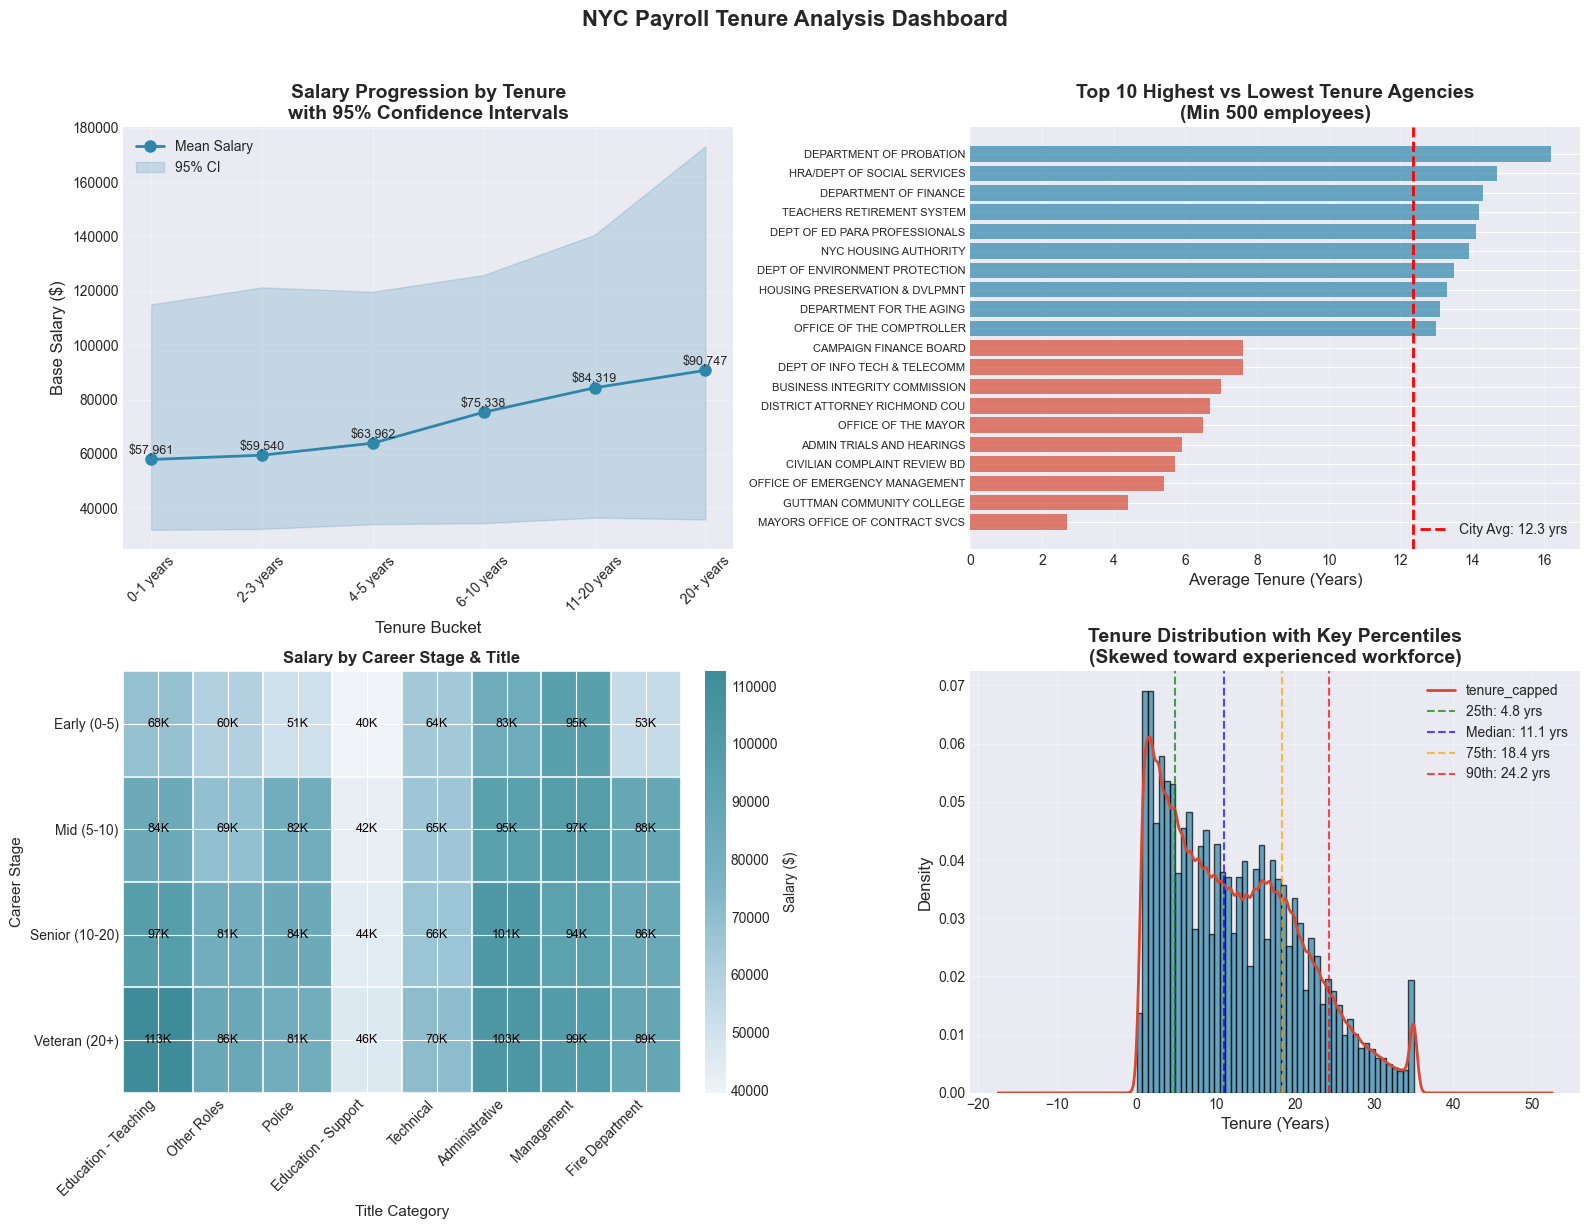

In [55]:
# CREATE KEY VISUALIZATIONS FOR TENURE ANALYSIS

# Set style for professional looking plots
from matplotlib.pyplot import axes


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

def step7_create_tenure_visualizations(df):
    """
    Create the 3 most important visualizations for tenure analysis
    """
    print("\n" + "=" * 60)
    print("STEP 7: CREATING TENURE VISUALIZATIONS")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # ============================================================
    # VISUALIZATION 1: Salary Progression with Confidence Bands
    # ============================================================
    ax1 = axes[0, 0]
    
    # Calculate mean and confidence intervals by tenure bucket
    tenure_order = ['0-1 years', '2-3 years', '4-5 years', '6-10 years', '11-20 years', '20+ years']
    means = []
    lower_bounds = []
    upper_bounds = []
    
    for bucket in tenure_order:
        bucket_data = df[df['tenure_bucket_simple'] == bucket]['Base Salary']
        means.append(bucket_data.mean())
        # 95% confidence interval
        lower_bounds.append(bucket_data.quantile(0.025))
        upper_bounds.append(bucket_data.quantile(0.975))
    
    ax1.plot(tenure_order, means, 'o-', linewidth=2, markersize=8, color='#2E86AB', label='Mean Salary')
    ax1.fill_between(tenure_order, lower_bounds, upper_bounds, alpha=0.2, color='#2E86AB', label='95% CI')
    ax1.set_xlabel('Tenure Bucket', fontsize=12)
    ax1.set_ylabel('Base Salary ($)', fontsize=12)
    ax1.set_title('Salary Progression by Tenure\nwith 95% Confidence Intervals', fontsize=14, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on points
    for i, (bucket, mean_val) in enumerate(zip(tenure_order, means)):
        ax1.text(i, mean_val + 2000, f'${mean_val:,.0f}', ha='center', fontsize=9)
    
    # ============================================================
    # VISUALIZATION 2: Top 10 High vs Low Tenure Agencies (Horizontal Bar Chart)
    # ============================================================
    ax2 = axes[0, 1]
    
    # Get top 10 and bottom 10 agencies (with min 500 employees)
    agency_stats = df.groupby('Agency Name').agg({
        'tenure_capped': 'mean',
        'Employee_Agency_Tenure': 'count'
    }).round(1)
    agency_stats = agency_stats[agency_stats['Employee_Agency_Tenure'] >= 500].sort_values('tenure_capped')
    
    # Take bottom 10 and top 10
    bottom10 = agency_stats.head(10)
    top10 = agency_stats.tail(10)
    combined = pd.concat([bottom10, top10])
    
    # Create horizontal bar chart
    colors = ['#D64933'] * 10 + ['#2E86AB'] * 10
    y_pos = range(len(combined))
    ax2.barh(y_pos, combined['tenure_capped'], color=colors, alpha=0.7)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(combined.index, fontsize=8)
    ax2.set_xlabel('Average Tenure (Years)', fontsize=12)
    ax2.set_title('Top 10 Highest vs Lowest Tenure Agencies\n(Min 500 employees)', fontsize=14, fontweight='bold')
    ax2.axvline(x=df['tenure_capped'].mean(), color='red', linestyle='--', linewidth=2, label=f'City Avg: {df["tenure_capped"].mean():.1f} yrs')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='x')
    
    # ============================================================
    # VISUALIZATION 3: Heatmap - Tenure, Salary, and Overtime Relationship
    # ============================================================
    # Alternative with adaptive grey (darker on light cells, lighter on dark cells)
    ax3 = axes[1, 0]

    # Create simpler tenure groups
    df['tenure_simple_group'] = pd.cut(df['tenure_capped'], bins=[0, 5, 10, 20, 35], 
                                        labels=['Early (0-5)', 'Mid (5-10)', 'Senior (10-20)', 'Veteran (20+)'])

    # Calculate heatmap data
    heatmap_data = df.groupby(['tenure_simple_group', 'Title_Category'], observed=False)['Base Salary'].mean().round(0).unstack()

    # Keep only top 8 most common title categories
    top_titles = df['Title_Category'].value_counts().head(8).index
    heatmap_data = heatmap_data[top_titles]

    # Use a softer, more pastel colormap
    from matplotlib.colors import LinearSegmentedColormap
    soft_blues = LinearSegmentedColormap.from_list('soft_blues', ['#F0F4F8', '#B8D4E3', '#7BB3C4', "#5BA1AE", "#3E8C9A"])

    im = ax3.imshow(heatmap_data.values, cmap=soft_blues, aspect='auto', interpolation='nearest')

    ax3.set_xticks(range(len(heatmap_data.columns)))
    ax3.set_xticklabels(heatmap_data.columns, rotation=45, ha='right', fontsize=10)
    ax3.set_yticks(range(len(heatmap_data.index)))
    ax3.set_yticklabels(heatmap_data.index, fontsize=10)
    ax3.set_xlabel('Title Category', fontsize=11)
    ax3.set_ylabel('Career Stage', fontsize=11)
    ax3.set_title('Salary by Career Stage & Title', fontsize=12, fontweight='bold')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax3, label='Salary ($)', fraction=0.046, pad=0.04)

    # Consistent grey for ALL annotations
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if not pd.isna(value):
                salary_k = value / 1000
                ax3.text(j, i, f'{salary_k:.0f}K', 
                        ha="center", va="center", 
                        color="#0E0101",  # Consistent grey
                        fontsize=9, 
                        fontweight='medium')

    # Add light grid lines for better readability
    ax3.set_xticks(np.arange(-0.5, len(heatmap_data.columns), 1), minor=True)
    ax3.set_yticks(np.arange(-0.5, len(heatmap_data.index), 1), minor=True)
    ax3.grid(which='minor', color='white', linestyle='-', linewidth=1.5, alpha=0.8)
    ax3.tick_params(which='minor', bottom=False, left=False)

    print(f"\n✓ Clean heatmap with consistent grey font and soft colors")
    
    # ============================================================
    #  Tenure Distribution Histogram
    # ============================================================
    ax4 = axes[1, 1]
    
    # Plot histogram with kernel density estimate
    ax4.hist(df['tenure_capped'], bins=50, alpha=0.7, color='#2E86AB', edgecolor='black', density=True)
    df['tenure_capped'].plot.kde(ax=ax4, color='#D64933', linewidth=2)
    
    # Add vertical lines for key percentiles
    percentiles = [25, 50, 75, 90]
    colors = ['green', 'blue', 'orange', 'red']
    labels = ['25th', 'Median', '75th', '90th']
    
    for p, color, label in zip(percentiles, colors, labels):
        value = df['tenure_capped'].quantile(p/100)
        ax4.axvline(x=value, color=color, linestyle='--', alpha=0.7, label=f'{label}: {value:.1f} yrs')
    
    ax4.set_xlabel('Tenure (Years)', fontsize=12)
    ax4.set_ylabel('Density', fontsize=12)
    ax4.set_title('Tenure Distribution with Key Percentiles\n(Skewed toward experienced workforce)', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('NYC Payroll Tenure Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(f'tenure_analysis_dashboard_{datetime.now().strftime("%Y%m%d_%H%M%S")}.png', 
                dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: tenure_analysis_dashboard.png")
    plt.show()
    
    return fig

# Run Step 7
fig = step7_create_tenure_visualizations(df)